<a href="https://colab.research.google.com/github/2403a54127-lab/FUTURE_DS_01_TASK2/blob/main/FUTURE_DS_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  CustomerID  Age Gender  TenureMonths SubscriptionType  MonthlyCharges  \
0      C0001   56   Male            22            Basic             299   
1      C0002   46   Male            47            Basic             699   
2      C0003   32   Male            30            Basic             499   
3      C0004   60   Male            43          Premium             699   
4      C0005   25   Male            48          Premium             499   

   SupportTickets  AvgLoginDays ContractType PaymentMethod    JoinDate  \
0               4            10      Monthly   Credit Card  2023-06-25   
1               1            20      Monthly           UPI  2023-06-15   
2               7             3      Monthly   Net Banking  2024-10-18   
3               4             6      Monthly           UPI  2025-04-21   
4               1             7      Monthly   Net Banking  2024-01-05   

   TotalCharges Churn  
0          6578    No  
1         32853    No  
2         14970   Yes  
3       

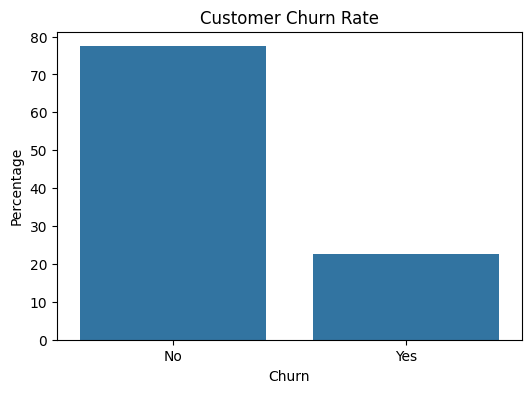

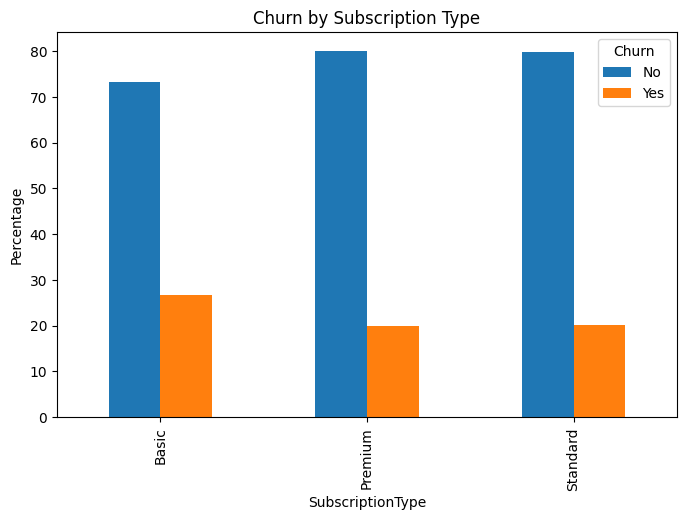

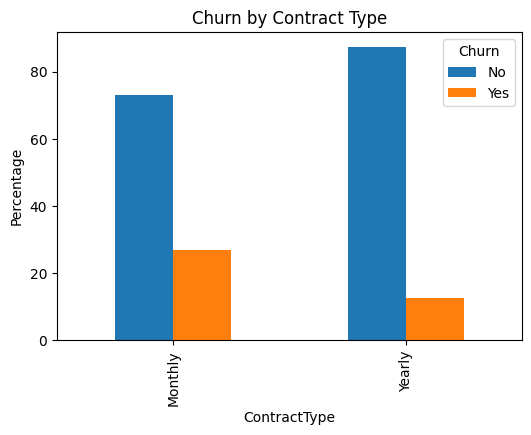

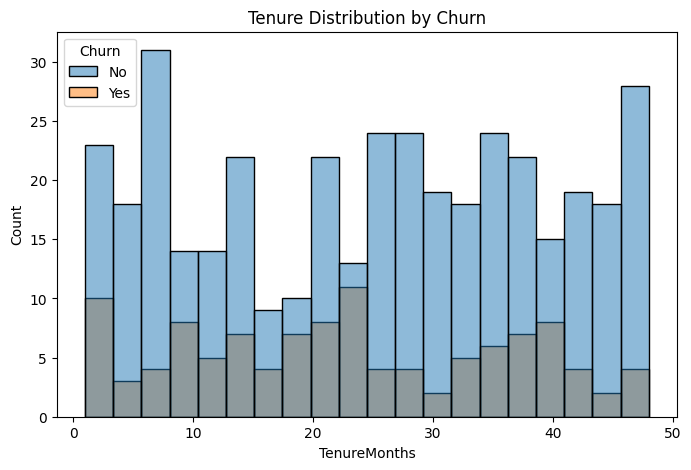

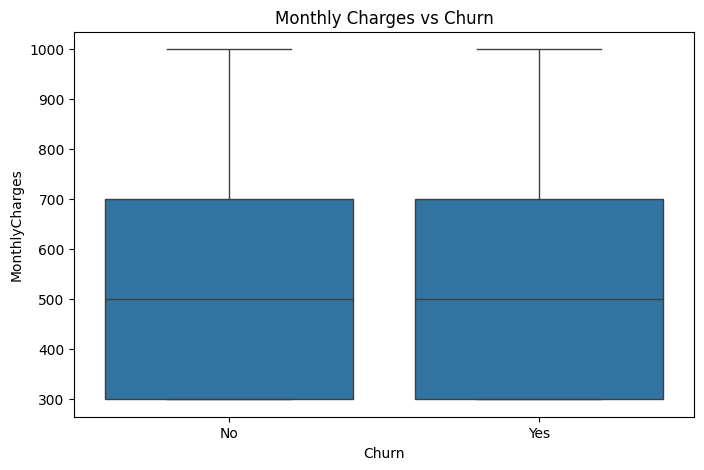

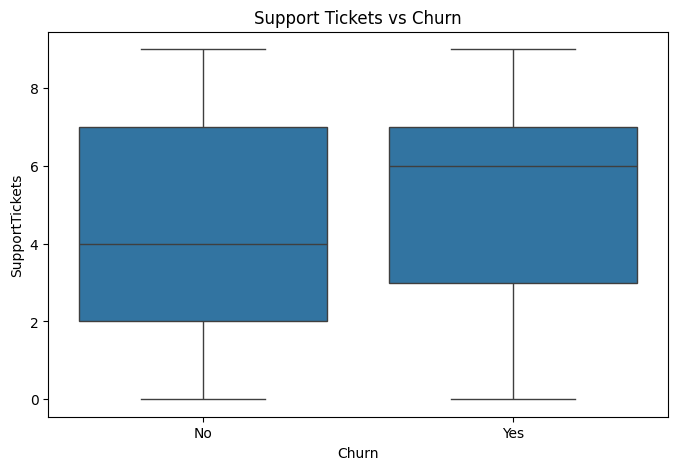

             TotalCustomers  Churned  RetentionRate
CohortMonth                                        
2023-01                  10        1      90.000000
2023-02                  18        3      83.333333
2023-03                  16        6      62.500000
2023-04                  12        1      91.666667
2023-05                  20        5      75.000000
2023-06                  12        2      83.333333
2023-07                  22        5      77.272727
2023-08                  14        3      78.571429
2023-09                  15        4      73.333333
2023-10                  15        2      86.666667
2023-11                  18        3      83.333333
2023-12                  18        5      72.222222
2024-01                  25        4      84.000000
2024-02                  16        4      75.000000
2024-03                  16        4      75.000000
2024-04                  13        5      61.538462
2024-05                  20        5      75.000000
2024-06     

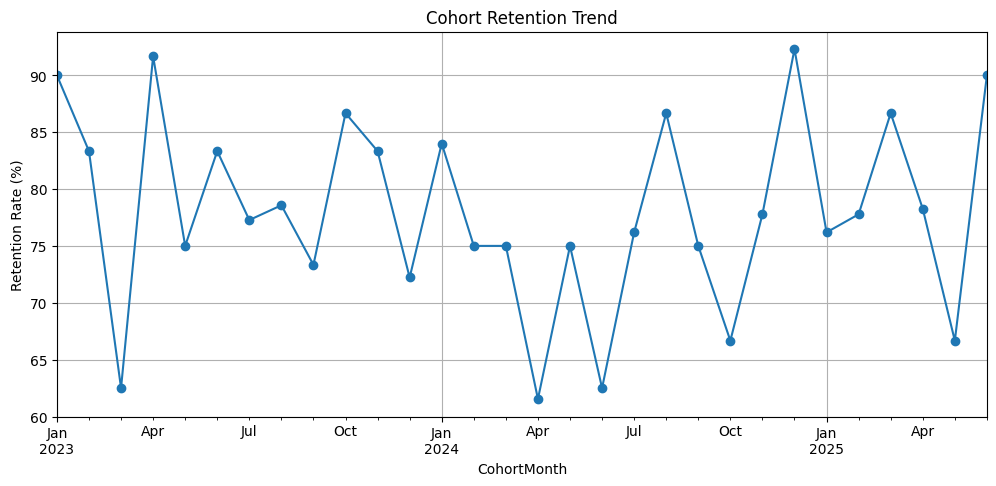

Average Customer Lifetime Value: ₹15,054.45

Average Metrics by Churn Status:
       TenureMonths  MonthlyCharges  SupportTickets  AvgLoginDays
Churn                                                            
No        25.015504      615.795866        4.385013     15.749354
Yes       22.955752      586.610619        5.132743     15.097345


In [1]:
# Customer Retention & Churn Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("customer_retention_churn_dataset.csv")

# Basic Information
print(df.head())
print(df.info())
print(df.describe())

# -------------------------------
# 1. Churn Rate Analysis
# -------------------------------
churn_rate = df['Churn'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))
sns.barplot(x=churn_rate.index, y=churn_rate.values)
plt.title("Customer Churn Rate")
plt.ylabel("Percentage")
plt.show()

# -------------------------------
# 2. Churn by Subscription Type
# -------------------------------
subscription_churn = pd.crosstab(
    df['SubscriptionType'],
    df['Churn'],
    normalize='index'
) * 100

subscription_churn.plot(kind='bar', figsize=(8,5))
plt.title("Churn by Subscription Type")
plt.ylabel("Percentage")
plt.show()

# -------------------------------
# 3. Churn by Contract Type
# -------------------------------
contract_churn = pd.crosstab(
    df['ContractType'],
    df['Churn'],
    normalize='index'
) * 100

contract_churn.plot(kind='bar', figsize=(6,4))
plt.title("Churn by Contract Type")
plt.ylabel("Percentage")
plt.show()

# -------------------------------
# 4. Tenure Analysis
# -------------------------------
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='TenureMonths', hue='Churn', bins=20)
plt.title("Tenure Distribution by Churn")
plt.show()

# -------------------------------
# 5. Monthly Charges Analysis
# -------------------------------
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

# -------------------------------
# 6. Support Tickets Analysis
# -------------------------------
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='SupportTickets', data=df)
plt.title("Support Tickets vs Churn")
plt.show()

# -------------------------------
# 7. Cohort Analysis
# -------------------------------

df['JoinDate'] = pd.to_datetime(df['JoinDate'])

df['CohortMonth'] = df['JoinDate'].dt.to_period('M')

cohort_data = df.groupby('CohortMonth').agg(
    TotalCustomers=('CustomerID', 'count'),
    Churned=('Churn', lambda x: (x=='Yes').sum())
)

cohort_data['RetentionRate'] = (
    (cohort_data['TotalCustomers'] - cohort_data['Churned'])
    / cohort_data['TotalCustomers']
) * 100

print(cohort_data)

plt.figure(figsize=(12,5))
cohort_data['RetentionRate'].plot(marker='o')
plt.title("Cohort Retention Trend")
plt.ylabel("Retention Rate (%)")
plt.grid(True)
plt.show()

# -------------------------------
# 8. Customer Lifetime Value
# -------------------------------

df['CustomerLifetimeValue'] = (
    df['MonthlyCharges'] * df['TenureMonths']
)

avg_clv = df['CustomerLifetimeValue'].mean()

print(f"Average Customer Lifetime Value: ₹{avg_clv:,.2f}")

# -------------------------------
# Top Retention Drivers
# -------------------------------

print("\nAverage Metrics by Churn Status:")
print(df.groupby('Churn')[
    ['TenureMonths','MonthlyCharges',
     'SupportTickets','AvgLoginDays']
].mean())